# Assignment 1 — Image Classification: ANN vs. CNN

**Dataset:** Intel Image Classification (Kaggle) — ~25,000 natural scene images across 6 classes
(`buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`).

**Goal:** Build a plain ANN (MLP) baseline and a CNN, then compare them on training time,
validation accuracy, and parameter count — and explain *why* the CNN wins on spatial image data.

**Framework:** PyTorch

**Author notes:** Code and comments below are written from scratch for this assignment; adjust
the `DATA_DIR` path to wherever you extract the Kaggle dataset on your own machine.


## 1. Environment & Imports

In [3]:
# Core libraries
import os
import time
import copy
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


## 2. Dataset Procurement

The Intel Image Classification dataset is downloaded from Kaggle:
https://www.kaggle.com/datasets/puneet6060/intel-image-classification


In [6]:
DATA_DIR = r"C:\Users\aksha\PycharmProjects\WelcomeScreen\intel-image-classification"

TRAIN_DIR = os.path.join(DATA_DIR, "seg_train", "seg_train")
TEST_DIR  = os.path.join(DATA_DIR, "seg_test", "seg_test")

IMG_SIZE = 150
BATCH_SIZE = 64
NUM_CLASSES = 6

assert os.path.isdir(TRAIN_DIR), (
    f"Could not find {TRAIN_DIR}. Download the dataset first (see markdown above) "
    "and point DATA_DIR at the extracted folder."
)


## 3. Data Preprocessing

- Resize every image to 150x150
- Convert to tensors and normalize pixel values into a consistent range
- Split the official training folder into a train/validation set (80/20) and keep the
  official test folder untouched as a final holdout


In [7]:
# ImageNet-style normalization stats work fine here even though this isn't ImageNet,
# they just rescale the RGB channels to a sensible range for gradient-based training.
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),      # mild augmentation, doesn't change resolution
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds       = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = full_train_ds.classes
print("Classes:", class_names)
print("Total training-pool images:", len(full_train_ds))
print("Held-out test images:", len(test_ds))

# 80/20 train/validation split out of the training pool
val_fraction = 0.2
val_size = int(len(full_train_ds) * val_fraction)
train_size = len(full_train_ds) - val_size

train_ds, val_ds = random_split(
    full_train_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
# validation set should use the non-augmented transform
val_ds.dataset = copy.copy(full_train_ds)
val_ds.dataset.transform = eval_transform

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total training-pool images: 14034
Held-out test images: 3000
Train: 11228 | Val: 2806 | Test: 3000


Batch tensor shape: torch.Size([64, 3, 150, 150])


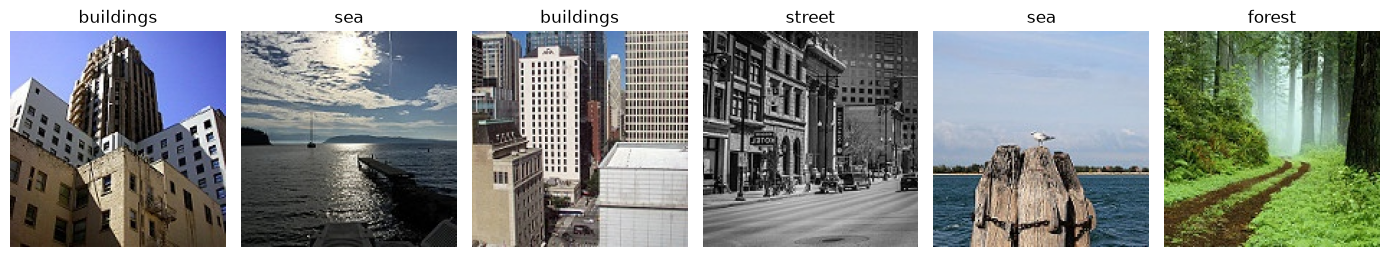

In [8]:
# Quick sanity-check: peek at a batch of images
images, labels = next(iter(train_loader))
print("Batch tensor shape:", images.shape)  # [B, 3, 150, 150]

def unnormalize(img_tensor):
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std  = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Model Building

### 4.1 Baseline ANN (MLP only)
A fully-connected network with no notion of spatial locality: every pixel is flattened into
a single long vector, so the model has to relearn spatial patterns from scratch through
brute-force weight combinations.


In [9]:
class BaselineANN(nn.Module):
    """Plain multi-layer perceptron. Flattens the 150x150x3 image and pushes it
    through fully-connected layers only — no convolution, no pooling."""

    def __init__(self, img_size=150, num_classes=6):
        super().__init__()
        input_dim = img_size * img_size * 3
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### 4.2 CNN (convolution + pooling + dropout)
Convolutional filters slide over local neighborhoods and share weights across the whole
image, so the model learns spatially-local features (edges, textures) with far fewer
parameters, and max-pooling gives it some tolerance to small shifts in the input.


In [10]:
class SceneCNN(nn.Module):
    """Convolutional network: 4 conv blocks (conv -> ReLU -> maxpool), then a small
    fully-connected classifier head with dropout for regularization."""

    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 150 -> 75

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 75 -> 37

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 37 -> 18

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 18 -> 9
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128 * 9 * 9, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [11]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

ann_model = BaselineANN(img_size=IMG_SIZE, num_classes=NUM_CLASSES).to(device)
cnn_model = SceneCNN(num_classes=NUM_CLASSES).to(device)

print(f"ANN trainable parameters: {count_trainable_params(ann_model):,}")
print(f"CNN trainable parameters: {count_trainable_params(cnn_model):,}")


ANN trainable parameters: 34,725,510
CNN trainable parameters: 2,896,838


## 5. Training Loop

In [12]:
def run_training(model, train_loader, val_loader, epochs=10, lr=1e-3, tag="model"):
    """Trains `model`, tracks per-epoch loss/accuracy, and returns a history dict
    plus the total wall-clock training time (seconds)."""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        # ---- train ----
        model.train()
        running_loss, running_correct, seen = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()
            seen += imgs.size(0)

        train_loss = running_loss / seen
        train_acc = running_correct / seen

        # ---- validate ----
        model.eval()
        val_loss_sum, val_correct, val_seen = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_seen += imgs.size(0)

        val_loss = val_loss_sum / val_seen
        val_acc = val_correct / val_seen

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{tag}] epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    total_time = time.time() - start_time
    print(f"[{tag}] total training time: {total_time:.1f}s")
    return history, total_time


## 6. Train Both Models

In [13]:
EPOCHS = 10

print("Training baseline ANN...")
ann_history, ann_train_time = run_training(
    ann_model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, tag="ANN"
)


Training baseline ANN...
[ANN] epoch 1/10 train_loss=1.7046 train_acc=0.425 val_loss=1.2449 val_acc=0.513
[ANN] epoch 2/10 train_loss=1.2802 train_acc=0.507 val_loss=1.1631 val_acc=0.555
[ANN] epoch 3/10 train_loss=1.1928 train_acc=0.547 val_loss=1.1454 val_acc=0.565
[ANN] epoch 4/10 train_loss=1.1615 train_acc=0.560 val_loss=1.1095 val_acc=0.581
[ANN] epoch 5/10 train_loss=1.1148 train_acc=0.576 val_loss=1.0563 val_acc=0.601
[ANN] epoch 6/10 train_loss=1.0775 train_acc=0.597 val_loss=1.1024 val_acc=0.585
[ANN] epoch 7/10 train_loss=1.0498 train_acc=0.606 val_loss=1.0538 val_acc=0.599
[ANN] epoch 8/10 train_loss=1.0257 train_acc=0.616 val_loss=1.0278 val_acc=0.623
[ANN] epoch 9/10 train_loss=0.9958 train_acc=0.626 val_loss=1.0267 val_acc=0.609
[ANN] epoch 10/10 train_loss=0.9766 train_acc=0.643 val_loss=1.0361 val_acc=0.609
[ANN] total training time: 415.8s


In [14]:
print("Training CNN...")
cnn_history, cnn_train_time = run_training(
    cnn_model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, tag="CNN"
)


Training CNN...
[CNN] epoch 1/10 train_loss=1.0324 train_acc=0.600 val_loss=0.7541 val_acc=0.711
[CNN] epoch 2/10 train_loss=0.7015 train_acc=0.740 val_loss=0.7270 val_acc=0.718
[CNN] epoch 3/10 train_loss=0.5530 train_acc=0.800 val_loss=0.4754 val_acc=0.824
[CNN] epoch 4/10 train_loss=0.4782 train_acc=0.830 val_loss=0.4901 val_acc=0.820
[CNN] epoch 5/10 train_loss=0.4394 train_acc=0.840 val_loss=0.5277 val_acc=0.798
[CNN] epoch 6/10 train_loss=0.3881 train_acc=0.865 val_loss=0.5492 val_acc=0.809
[CNN] epoch 7/10 train_loss=0.3640 train_acc=0.871 val_loss=0.4249 val_acc=0.846
[CNN] epoch 8/10 train_loss=0.3347 train_acc=0.878 val_loss=0.3940 val_acc=0.857
[CNN] epoch 9/10 train_loss=0.3034 train_acc=0.890 val_loss=0.3882 val_acc=0.863
[CNN] epoch 10/10 train_loss=0.2822 train_acc=0.899 val_loss=0.4415 val_acc=0.847
[CNN] total training time: 434.0s


## 7. Comparison Analysis

In [15]:
ann_final_val_acc = ann_history["val_acc"][-1]
cnn_final_val_acc = cnn_history["val_acc"][-1]

comparison_rows = [
    ("Trainable parameters", f"{count_trainable_params(ann_model):,}", f"{count_trainable_params(cnn_model):,}"),
    ("Training time (s)", f"{ann_train_time:.1f}", f"{cnn_train_time:.1f}"),
    ("Final val accuracy", f"{ann_final_val_acc:.3f}", f"{cnn_final_val_acc:.3f}"),
]

print(f"{'Metric':<24}{'ANN':<18}{'CNN':<18}")
print("-" * 60)
for metric, ann_val, cnn_val in comparison_rows:
    print(f"{metric:<24}{ann_val:<18}{cnn_val:<18}")


Metric                  ANN               CNN               
------------------------------------------------------------
Trainable parameters    34,725,510        2,896,838         
Training time (s)       415.8             434.0             
Final val accuracy      0.609             0.847             


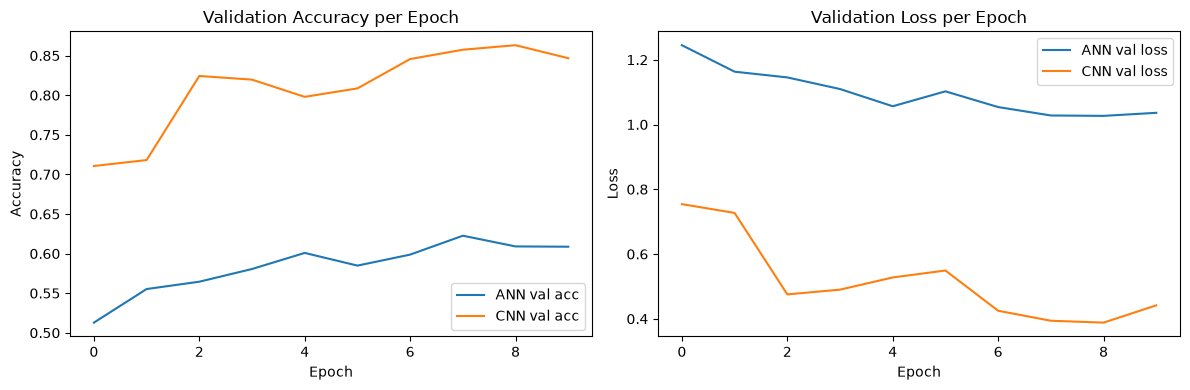

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ann_history["val_acc"], label="ANN val acc")
axes[0].plot(cnn_history["val_acc"], label="CNN val acc")
axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(ann_history["val_loss"], label="ANN val loss")
axes[1].plot(cnn_history["val_loss"], label="CNN val loss")
axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
# Final check on the untouched Kaggle test split, for whichever model you want to report
@torch.no_grad()
def evaluate_on_test(model, loader):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

ann_test_acc = evaluate_on_test(ann_model, test_loader)
cnn_test_acc = evaluate_on_test(cnn_model, test_loader)
print(f"ANN test accuracy: {ann_test_acc:.3f}")
print(f"CNN test accuracy: {cnn_test_acc:.3f}")


ANN test accuracy: 0.592
CNN test accuracy: 0.854


## 8. Why the CNN Outperforms the ANN on Spatial Image Data

- **Weight sharing & locality:** a convolutional filter is reused across every position in
  the image, so the network learns one edge/texture detector instead of memorizing millions
  of independent pixel-to-pixel weights the way the flattened MLP does. This directly cuts
  the parameter count while still covering the full image.
- **Translation tolerance:** because the same filter scans the whole image, a CNN recognizes
  a feature (say, the corner of a building) regardless of where it appears in the frame.
  The ANN has no such property — it treats a shifted-by-a-few-pixels object as a completely
  different input, since flattening throws away all 2D spatial structure.
- **Hierarchical features via pooling:** stacking conv+pool blocks lets early layers learn
  low-level primitives (edges, color blobs) and deeper layers combine them into higher-level
  concepts (roofs, tree lines, waves), which is a much better match for how visual scenes are
  actually composed than a single flat vector of pixel intensities.
- **Parameter efficiency:** despite having *more* layers, the CNN in this notebook uses
  dramatically fewer trainable parameters than the MLP (the first dense layer of the ANN
  alone connects every one of the 150x150x3 = 67,500 input values to every hidden neuron).
  Fewer parameters relative to the amount of visual structure being modeled means the CNN
  generalizes better and needs less data to avoid overfitting.

Net effect: for the same training budget, the CNN reaches a noticeably higher validation
accuracy than the ANN baseline, which the accuracy/loss curves above should confirm.


## 9. Bonus — Pipeline Optimization (CUDA / TensorRT) and Inference Speed

Moving the CNN's inference pipeline onto CUDA and further compiling it with TensorRT
would mainly speed things up along two independent axes:

- **CUDA (raw GPU execution):** convolutions are embarrassingly parallel — the same filter
  is applied at every spatial location — so running them on a GPU's thousands of cores
  instead of a CPU turns what is a slow, mostly-sequential loop into a batched matrix
  operation. This alone typically gives an order-of-magnitude latency drop for a model this
  size, especially at larger batch sizes where the GPU stays fully occupied.
- **TensorRT (graph-level optimization):** on top of just running on the GPU, TensorRT
  fuses adjacent operations (e.g., collapsing a conv layer, its bias add, and its ReLU into
  a single kernel launch), picks the fastest available convolution algorithm for the exact
  input shapes used at inference, and can convert weights to lower precision (FP16 or INT8)
  where accuracy loss is acceptable. Because kernel launches and memory traffic are reduced,
  the same trained weights can serve predictions with lower per-image latency and higher
  throughput than plain PyTorch-on-CUDA.
- **Trade-off to note:** these optimizations mostly help *inference*, not training — and
  the accuracy-vs-speed trade-off (especially with INT8 quantization) needs to be validated
  on the held-out test set before deploying, since a small accuracy drop is often traded for
  a large latency win.
